# AI for Cognitive Ultrasound Imaging
### IEEE IUS 2026 Short Course

Welcome! In this hands-on notebook we build a basic **perception-action loop** that drives intelligent, adaptive focused transmit steering, a core idea behind cognitive ultrasound.

We use a [Flow Matching model](https://zea.readthedocs.io/en/latest/_autosummary/zea.models.flow_matching.html#zea.models.flow_matching.FlowMatchingModel) (the modern, faster-sampling cousin of diffusion models, now native in [`zea`](https://github.com/tue-bmd/zea)) to implement perception-as-inference, with [greedy entropy minimization](https://zea.readthedocs.io/en/latest/_autosummary/zea.agent.selection.html#zea.agent.selection.GreedyEntropy) as our action selection policy.

This notebook accompanies the IEEE IUS 2026 short course [AI for Cognitive Ultrasound Imaging](https://ieee-ius.org/2026/short-course/ai-for-cognitive-ultrasound-imaging), organized by Yonina Eldar, Marcin Lewandowski and Ruud van Sloun. The notebook part of the course is brought to you by [Tristan Stevens](https://github.com/tristan-deep), [Oisín Nolan](https://github.com/OisinNolan) and [Wessel van Nierop](https://github.com/wesselvannierop), maintainers of `zea`.

Feel free to play around with the settings throughout, this notebook is meant to be explored, not just run! 🚀

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/ius-2026-cogus-workshop/blob/main/ius_2026_cogus_workshop.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/ius-2026-cogus-workshop/blob/main/ius_2026_cogus_workshop.ipynb)
&nbsp;
[![Hugging Face model](https://img.shields.io/badge/Hugging%20Face-Model-yellow?logo=huggingface)](https://huggingface.co/zeahub/flowmatching-echonetlvh)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Running on CPU may be very slow.

If you are running in Colab (recommended, click the badge above), enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀

In [1]:
%%capture
%pip install "zea[jax]>=0.1.5" tabulate

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from keras import ops
from matplotlib import animation
from tabulate import tabulate
from tqdm import tqdm

from zea import init_device, metrics
from zea.agent import masks
from zea.agent.selection import EquispacedLines, GreedyEntropy, UniformRandomLines
from zea.data import Dataset
from zea.func import translate
from zea.models.flow_matching import FlowMatchingModel
from zea.models.lpips import LPIPS
from zea.ops import Pipeline, ScanConvert
from zea.visualize import plot_image_grid, set_mpl_style

zea: Using backend 'jax'


In [4]:
n_prior_samples = 4  # particles representing the prior belief
n_unconditional_steps = 90  # flow steps for a sample from the prior
n_conditional_samples = 4  # particles representing the posterior belief
n_conditional_steps = 200  # length of the full posterior flow schedule
n_initial_conditional_steps = 180  # steps skipped when warm-starting on a new frame
n_actions = 16  # focused lines acquired per frame, out of 256 possible ones

We will work with the GPU if available, and initialize using `init_device` to pick the best available device. Also, (optionally), we will set the matplotlib style for plotting.

In [5]:
init_device(verbose=False)
set_mpl_style()

## Load dataset and model

The generative model and the agent both live in the **polar** domain: the raw acquisition
grid, where one focused transmit is exactly one column of pixels. That is not what a scanner
puts on screen, so `zea` datasets carry both representations. `data.image` is the
scan-converted image (the familiar fan), and `data.image_polar` is the grid the transmits
were fired on. We load `image_polar` and only scan convert at the very end, for plotting.
Scan converting the target up front would mean acquiring "lines" of an image that has
already been warped into a fan, and the agent would be steering in the wrong coordinates.

In [6]:
# load generative model - flow matching replaces the older diffusion models used in earlier zea releases
model = FlowMatchingModel.from_preset("flowmatching-echonetlvh")
img_shape = model.input_shape[:2]
frame_height, frame_width, _ = model.input_shape
vmin, vmax = model.input_range  # used throughout for plotting and preprocessing


# load camus dataset
dataset = Dataset(["hf://zeahub/camus-sample/val", "hf://zeahub/camus-sample/train"])


def preprocess(sample):
    """Read one cine loop in the polar domain and map it onto the model's input range."""
    sample = sample.data.image_polar.values[:]  # (n_frames, H, W) cine loop
    sample = ops.expand_dims(sample, axis=-1)
    sample = ops.image.resize(sample, img_shape)
    dynamic_range = (-40, 0)
    sample = ops.clip(sample, dynamic_range[0], dynamic_range[1])
    sample = translate(sample, dynamic_range, (vmin, vmax))
    return sample[..., 0]  # remove channel dim


data = preprocess(dataset[0])

I0000 00:00:1789051966.490774  223663 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789051968.730834  223663 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Visualize target sequence
Here we load a sequence of ultrasound frames from the CAMUS validation set. This will be our 'ground truth' target sequence, that the agent will need to reconstruct from a small budget of focused scan lines

zea: WARNING GPU support for order > 1 is not available. Disabling jit for ScanConvert.


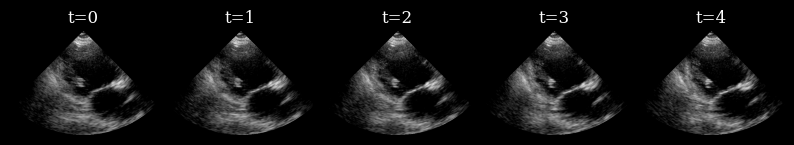

In [7]:
scan_convert = Pipeline([ScanConvert(order=2, jit_compile=False)])
parameters = {
    "theta_range": [-0.78, 0.78],  # [-45, 45] in radians
    "rho_range": [0, 1],
}
parameters = scan_convert.prepare_parameters(**parameters)


def uncertainty_to_image(variance):
    """Map a variance map onto the image range so it can be plotted beside the images.

    The top percentile is clipped away first, otherwise a handful of hot pixels
    squashes the rest of the map to black.
    """
    upper = np.percentile(ops.convert_to_numpy(variance), 99)
    return translate(ops.clip(variance, 0.0, upper), (0.0, upper), (vmin, vmax))


data_sc = scan_convert(data=data, **parameters)["data"]

n_frames_to_plot = 5
fig, _ = plot_image_grid(
    data_sc[:n_frames_to_plot],
    titles=[f"t={t}" for t in range(n_frames_to_plot)],
    ncols=n_frames_to_plot,
    remove_axis=True,
    vmin=vmin,
    vmax=vmax,
)

## Simulate Focused Line Acquisition
We use a simple masking operator to simulate acquiring a set of focused lines from the tissue, where each line reveals a vertical column of pixels, in the polar domain, of the target.

In [8]:
def simulate_acquisition(full_frame, mask):
    measurement = full_frame[None, ...] * mask
    return measurement, mask

### Sampling from the prior

Initially, we have not yet acquired any measurements, so we draw samples from the prior to drive our actions.

90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 176ms/step


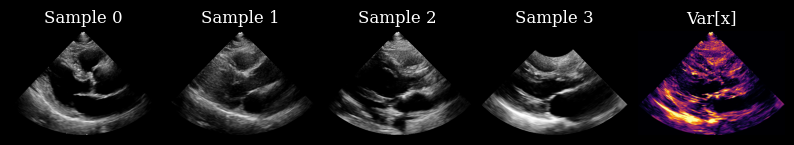

In [9]:
prior_samples = model.sample(
    n_samples=n_prior_samples, n_steps=n_unconditional_steps, verbose=True
)
prior_samples_sc = scan_convert(data=ops.squeeze(prior_samples, axis=-1), **parameters)[
    "data"
]
prior_variance = ops.nan_to_num(ops.var(prior_samples_sc, axis=0))
fig, _ = plot_image_grid(
    list(prior_samples_sc) + [uncertainty_to_image(prior_variance)],
    titles=[f"Sample {i}" for i in range(n_prior_samples)] + ["Var[x]"],
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * n_prior_samples + ["inferno"],
)

Next, we implement a perception-action loop, using a greedy entropy minimization strategy to select which lines to acquire next in the sequence. Each set of generated posterior samples at time $t$ are used as _initial samples_ for the reverse flow at time $t+1$ [1], ensuring that we generate a reconstructed sequence that is coherent over time.

[1] https://ieeexplore.ieee.org/document/10889752

### Posterior sampling

In [10]:
random_line_selector = UniformRandomLines(
    n_actions=n_actions,
    n_possible_actions=frame_width,
    img_width=frame_width,
    img_height=frame_height,
)
selected_lines, measurement_mask = random_line_selector.sample(batch_size=1)
target_frame = data[0]
measurements, measurement_mask = simulate_acquisition(target_frame, measurement_mask)
posterior_samples = model.posterior_sample(
    measurements=measurements[..., None],  # add channel dim
    mask=measurement_mask[..., None],  # add channel dim
    initial_samples=None,
    n_samples=n_conditional_samples,
    n_steps=n_conditional_steps,
    omega=10,
    initial_step=0,
)

In [11]:
# Postprocessing: `posterior_sample` returns (n_samples, height, width, 1)
posterior_samples_sc = scan_convert(data=posterior_samples[..., 0], **parameters)[
    "data"
]
measurements_sc = scan_convert(data=measurements, **parameters)["data"]
variances_sc = scan_convert(
    data=ops.var(posterior_samples, axis=0, keepdims=True)[..., 0],
    **(parameters | {"fill_value": 0.0}),
)["data"]
posterior_mean_sc = scan_convert(
    data=ops.mean(posterior_samples, axis=0, keepdims=True)[..., 0], **parameters
)["data"]

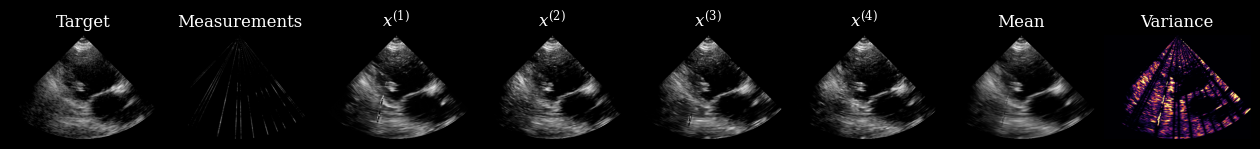

In [12]:
# plot moments of the posterior
panels = [
    data_sc[0],
    measurements_sc[0],
    *posterior_samples_sc,
    posterior_mean_sc[0],
    uncertainty_to_image(variances_sc[0]),
]
titles = [
    "Target",
    "Measurements",
    *[rf"$x^{{({i + 1})}}$" for i in range(n_conditional_samples)],
    "Mean",
    "Variance",
]
fig, ims = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * (len(panels) - 1) + ["inferno"],
)

### A simple action selection function

`zea` ships [`GreedyEntropy`](https://zea.readthedocs.io/en/latest/_autosummary/zea.agent.selection.html#zea.agent.selection.GreedyEntropy),
which scores every pixel by the entropy of a Gaussian mixture fitted to the particles. Here we
write a cheaper cousin that scores pixels by their plain variance, to show how little is needed
to define your own policy: reduce the belief to a per-line uncertainty, then greedily take the
most uncertain line while damping its neighbours (observing one line also tells you something
about the lines next to it).

In [13]:
class GreedyVariance(GreedyEntropy):
    """Greedily select the lines with maximum variance."""

    def sample(self, particles):
        """Sample the action using the greedy variance method.

        Args:
            particles (Tensor): Particles of shape (batch_size, n_particles, height, width)

        Returns:
            Tuple[Tensor, Tensor]:
                - Newly selected lines as k-hot vectors, shaped (batch_size, n_possible_actions)
                - Masks of shape (batch_size, img_height, img_width)
        """
        pixelwise_variance = ops.var(particles, axis=1)  # [batch_size, height, width]
        # we sum across the variances in each line to get a measure of line-wise uncertainty
        linewise_variance = ops.sum(pixelwise_variance, axis=1)  # [batch_size, width]

        # Greedily select best line, reweight variances, and repeat
        all_selected_lines = []
        for _ in range(self.n_actions):
            max_variance_line = ops.argmax(linewise_variance, axis=1)
            linewise_variance = self.reweight_entropies_around_line_vmap(
                linewise_variance, max_variance_line
            )
            all_selected_lines.append(max_variance_line)

        selected_lines_k_hot = masks.indices_to_k_hot(
            ops.stack(all_selected_lines, axis=1), self.n_possible_actions
        )
        return selected_lines_k_hot, self.lines_to_im_size(selected_lines_k_hot)

In [14]:
def belief_distribution_to_reconstruction(belief_distribution):
    """
    Args:
      belief_distribution: Tensor of shape (n_frames, n_particles, height, width, 1)
    Returns:
      reconstruction: Tensor of shape (n_frames, height, width, 1)
    """
    return belief_distribution[
        :, 0, ...
    ]  # selects the first posterior sample for each frame

In [15]:
def run_perception_action_loop(data, action_selector):
    # select the first actions based on the prior samples
    prior_samples_batched = prior_samples[None, ..., 0]  # add batch, remove channel
    _, measurement_mask = action_selector.sample(prior_samples_batched)
    # initialise the previous samples as the prior samples
    previous_samples = prior_samples

    belief_distributions = []
    measurements = []
    for target_frame in tqdm(data):
        # perception
        measurements_t, measurement_mask_t = simulate_acquisition(
            target_frame, measurement_mask
        )
        posterior_samples = model.posterior_sample(
            measurements=measurements_t[..., None],  # add channel dim
            mask=measurement_mask_t[..., None],  # add channel dim
            initial_samples=previous_samples,
            n_samples=n_conditional_samples,
            n_steps=n_conditional_steps,
            omega=10,
            initial_step=n_initial_conditional_steps,
        )

        # action
        # posterior_samples is (n_samples, H, W, 1); the action selector expects a batch axis
        _, measurement_mask = action_selector.sample(posterior_samples[None, ..., 0])

        # gather the selected measurements and reconstructions for visualization
        belief_distributions.append(posterior_samples)
        measurements.append(measurements_t)
        # reset the previous_samples
        previous_samples = posterior_samples

    return ops.convert_to_tensor(belief_distributions), ops.convert_to_tensor(
        measurements
    )

In [16]:
# initialize the action selector
greedy_variance_action_selector = GreedyVariance(
    n_actions=n_actions,
    n_possible_actions=frame_width,
    img_width=frame_width,
    img_height=frame_height,
)

# run the perception action loop
belief_distributions, measurements = run_perception_action_loop(
    data, greedy_variance_action_selector
)

100%|██████████| 17/17 [00:57<00:00,  3.38s/it]


In [17]:
reconstructions = belief_distribution_to_reconstruction(belief_distributions)
reconstructions_sc = scan_convert(data=reconstructions[..., 0], **parameters)["data"]
measurements_sc = scan_convert(data=measurements[:, 0, ...], **parameters)["data"]
variances_sc = scan_convert(
    data=ops.var(belief_distributions, axis=1)[..., 0],
    **(parameters | {"fill_value": 0.0}),
)["data"]
variances_sc = uncertainty_to_image(variances_sc)

## Visualize the results
Finally, we visualize our reconstructed sequence, along with the selected measurements and posterior variance at each step. The agent's goal of minizing posterior entropy is reflected in the low posterior variance throughout the sequence. You can see that the agent is quickly able to reduce the uncertainty after the first frame, when it was able to observe using acquisition of the first focused lines.

In [18]:
# plot image
fig, ims = plot_image_grid(
    [data_sc[0], measurements_sc[0], reconstructions_sc[0], variances_sc[0]],
    titles=["Target", "Measurements", "Reconstruction", "Variance"],
    ncols=4,
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * 3 + ["inferno"],
    figsize=(11, 4),
)


def update(frame):
    ims[0].set_array(data_sc[frame])
    ims[1].set_array(measurements_sc[frame])
    ims[2].set_array(reconstructions_sc[frame])
    ims[3].set_array(variances_sc[frame])

    return ims


ani = animation.FuncAnimation(fig, update, frames=len(data_sc), blit=True, interval=100)
plt.close(fig)
HTML(ani.to_jshtml())

## Does adaptive steering actually pay off?

We have watched one agent reconstruct one sequence, which is a nice picture but not yet
evidence. The claim behind cognitive ultrasound is that *choosing where to look based on what
you currently believe* beats a fixed scan pattern at the same cost. So let us put the agent up
against two belief-agnostic baselines, all spending the exact same budget of
`n_actions` lines per frame on the same sequence:

| Policy | What it does |
| --- | --- |
| **Equispaced sweep** | classic uniform undersampling, shifted one line per frame |
| **Uniform random** | a fresh random subset of lines every frame |
| **Greedy variance** | our agent, steering towards whatever it is least sure about |

We score each with PSNR (pixel fidelity, higher is better) and
[LPIPS](https://zea.readthedocs.io/en/latest/_autosummary/zea.models.lpips.html) (perceptual
distance, lower is better). Both baselines ignore the belief, so we can express them as tiny
subclasses that accept the same `sample(particles)` call and simply throw the particles away.

In [19]:
class RandomLines(UniformRandomLines):
    """Belief-agnostic baseline: a fresh random subset of lines every frame."""

    def sample(self, particles):
        del particles  # a random policy has no use for the belief
        return super().sample(batch_size=1)


class SweepingLines(EquispacedLines):
    """Belief-agnostic baseline: an equispaced grid, swept one line further each frame."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.current_lines = None

    def sample(self, particles):
        del particles  # the sweep is scripted in advance
        self.current_lines, mask = super().sample(self.current_lines)
        return self.current_lines, mask

In [20]:
lpips_model = LPIPS.from_preset("lpips")


def to_lpips(sequence):
    """Grayscale in the model's range -> rgb in [-1, 1], which is what lpips expects."""
    return ops.repeat(translate(sequence, (vmin, vmax), (-1, 1))[..., None], 3, axis=-1)


def evaluate(reconstruction, target):
    """Score a reconstructed sequence against its target, in the polar domain."""
    reconstruction = ops.clip(reconstruction, vmin, vmax)
    psnr = metrics.psnr(target, reconstruction, max_val=vmax - vmin)
    lpips = ops.mean(lpips_model((to_lpips(reconstruction), to_lpips(target))))
    return float(psnr), float(lpips)

In [21]:
selector_kwargs = dict(
    n_actions=n_actions,
    n_possible_actions=frame_width,
    img_width=frame_width,
    img_height=frame_height,
)
baselines = {
    "Equispaced sweep": SweepingLines(**selector_kwargs),
    "Uniform random": RandomLines(**selector_kwargs),
}

# the greedy agent already ran above, so we only pay for the two baselines here
runs = {}
for name, action_selector in baselines.items():
    print(name)
    beliefs, _ = run_perception_action_loop(data, action_selector)
    runs[name] = belief_distribution_to_reconstruction(beliefs)[..., 0]
runs["Greedy variance (agent)"] = reconstructions[..., 0]

table = [["Policy", "PSNR (↑)", "LPIPS (↓)"]]
for name, reconstruction in runs.items():
    psnr, lpips = evaluate(reconstruction, data)
    table.append([name, f"{psnr:.2f}", f"{lpips:.3f}"])

print("\n")
print(tabulate(table, headers="firstrow", tablefmt="fancy_grid"))

Equispaced sweep


100%|██████████| 17/17 [00:56<00:00,  3.30s/it]


Uniform random


100%|██████████| 17/17 [00:55<00:00,  3.29s/it]




╒═════════════════════════╤════════════╤═════════════╕
│ Policy                  │   PSNR (↑) │   LPIPS (↓) │
╞═════════════════════════╪════════════╪═════════════╡
│ Equispaced sweep        │      15.29 │       0.512 │
├─────────────────────────┼────────────┼─────────────┤
│ Uniform random          │      17.61 │       0.452 │
├─────────────────────────┼────────────┼─────────────┤
│ Greedy variance (agent) │      18.76 │       0.387 │
╘═════════════════════════╧════════════╧═════════════╛


And the same comparison as a picture, half-way through the loop. Both fixed patterns leave the
tell-tale radial striping of undersampled focused imaging, while the agent, spending the very
same number of lines, lands closer to the target. Note that everything here is stochastic (the
prior samples, the random lines, the posterior draws), so the exact numbers move between runs.

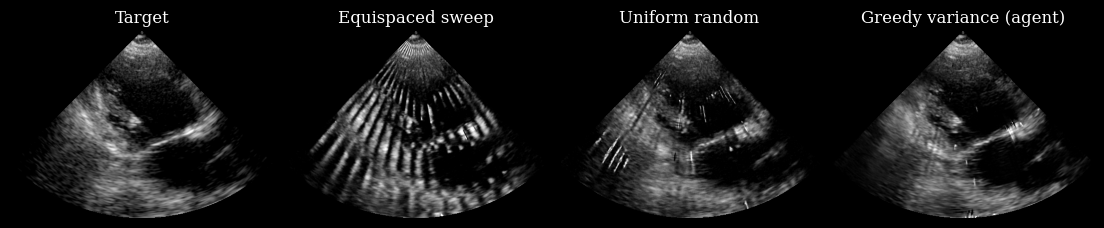

In [22]:
frame = len(data) // 2
panels = [data_sc[frame]]
titles = ["Target"]
for name, reconstruction in runs.items():
    panels.append(
        scan_convert(data=reconstruction[frame][None], **parameters)["data"][0]
    )
    titles.append(name)

fig, _ = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    figsize=(14, 4),
)

Your turn 🔧 The agent is deliberately simple, and every piece of it is a knob:

- **Action selection.** `GreedyVariance` scores lines by variance. Try `GreedyEntropy`
  (the Gaussian-mixture entropy `zea` ships), or `CovarianceSamplingLines`, or write a
  policy that keeps a memory of where it has already looked.
- **Reconstruction.** `belief_distribution_to_reconstruction` throws away three of the four
  particles. Returning the posterior mean instead is a one-line change.
- **Budget.** Lower `n_actions` until the agent breaks, and see whether the adaptive policy
  degrades more gracefully than the fixed ones.

See you at IUS 2026! 🎉